In [1]:
!git clone https://github.com/fastai/course-v3.git
!mv course-v3/nbs/dl2/exp . # Move the exp folder to your current directory

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 38.15 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.


In [3]:
from exp.nb_07a import *

In [4]:
from fastai.data.external import untar_data, URLs
import pathlib

# 1. Get the URL for Imagenette 160px version
# URLs.IMAGENETTE_160 is 'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz'
data_url = URLs.IMAGENETTE_160

# 2. Download and untar (extract) the data
# untar_data returns a pathlib.Path object to the extracted folder
path = untar_data(data_url)

print(f"Imagenette downloaded and extracted to: {path}")

# 3. List the contents to see the structure (train/valid folders)
print(f"Contents: {list(path.ls())}")

<div><progress max="99003388" value="99008512"></progress> 100.01% [99008512/99003388 00:02&lt;00:00]</div>

Imagenette downloaded and extracted to: /root/.fastai/data/imagenette2-160
Contents: [Path('/root/.fastai/data/imagenette2-160/noisy_imagenette.csv'), Path('/root/.fastai/data/imagenette2-160/.DS_Store'), Path('/root/.fastai/data/imagenette2-160/val'), Path('/root/.fastai/data/imagenette2-160/train')]


## Image ItemList
Previously we were reading in to RAM the whole MNIST dataset at once, loading it as a pickle file. We can't do that for datasets larger than our RAM capacity, so instead we leave the images on disk and just grab the ones we need for each mini-batch as we use them.

Let's use the imagenette dataset and build the data blocks we need along the way.

### Get images

In [5]:
path = untar_data(data_url)
path

Path('/root/.fastai/data/imagenette2-160')

To be able to look at what's inside a directory from a notebook, we add the `.ls` method to `Path` with a monkey-patch.

In [6]:
import PIL,os,mimetypes
Path.ls = lambda x: list(x.iterdir())

how easy it is to add stuff to the stdlib - can just take the class and add a fn to it

In [7]:
path.ls()

[Path('/root/.fastai/data/imagenette2-160/noisy_imagenette.csv'),
 Path('/root/.fastai/data/imagenette2-160/.DS_Store'),
 Path('/root/.fastai/data/imagenette2-160/val'),
 Path('/root/.fastai/data/imagenette2-160/train')]

In [8]:
list(path.iterdir())

[Path('/root/.fastai/data/imagenette2-160/noisy_imagenette.csv'),
 Path('/root/.fastai/data/imagenette2-160/.DS_Store'),
 Path('/root/.fastai/data/imagenette2-160/val'),
 Path('/root/.fastai/data/imagenette2-160/train')]

wihin val we have 1 directory for each category:

In [9]:
(path/'val').ls()

[Path('/root/.fastai/data/imagenette2-160/val/n01440764'),
 Path('/root/.fastai/data/imagenette2-160/val/n03000684'),
 Path('/root/.fastai/data/imagenette2-160/val/n03028079'),
 Path('/root/.fastai/data/imagenette2-160/val/n03888257'),
 Path('/root/.fastai/data/imagenette2-160/val/n03394916'),
 Path('/root/.fastai/data/imagenette2-160/val/n03425413'),
 Path('/root/.fastai/data/imagenette2-160/val/n03445777'),
 Path('/root/.fastai/data/imagenette2-160/val/n03417042'),
 Path('/root/.fastai/data/imagenette2-160/val/n02102040'),
 Path('/root/.fastai/data/imagenette2-160/val/n02979186')]

Let's have a look inside a class folder (the first class is tench):

In [10]:
path_tench = path/'val'/'n01440764'

In [11]:
img_fn = path_tench.ls()[0]
img_fn

Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG')

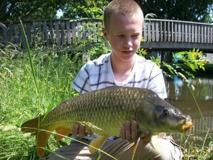

In [12]:
img = PIL.Image.open(img_fn)
img

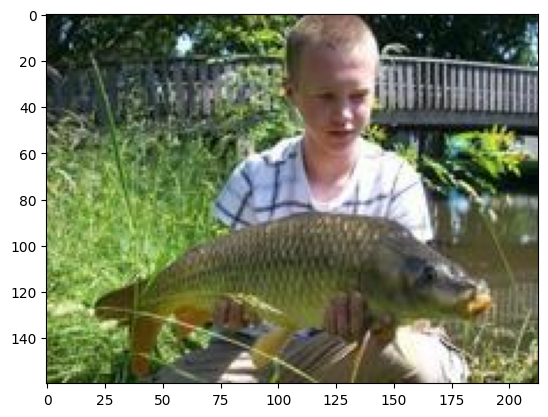

In [13]:
plt.imshow(img)

In [14]:
import numpy
imga = numpy.array(img)

In [15]:
imga.shape

(160, 213, 3)

In [16]:
imga[:10,:10,0]

array([[  7,  21,   1,   8,  20,  12,  22,  12,   1,   7],
       [ 14,   8,   0,  19,  29,   9,  10,  24,  20,  22],
       [  9,   6,  18,  20,  16,   6,  17,  63,  54,  29],
       [  2,  12,  35,  13,   8,  18,  19,  53,  31,  59],
       [  8,  13,  33,  18,  19,  24,   5,  21,  46, 101],
       [ 15,  16,  30,  26,  14,   1,  15,  67, 110, 109],
       [ 15,  26,  23,  21,   6,   0,  41, 101, 105,  79],
       [ 16,  30,   7,   8,  19,  20,  47,  53,  78,  44],
       [ 17,  24,  19,  12,  14,  13,  45, 102,  25,  26],
       [ 30,  16,  12,  18,  17,  16,  64, 134,  79,   0]], dtype=uint8)

Just in case there are other files in the directory (models, texts...) we want to keep only the images.  
Let's not write it out by hand, but instead use what's already on our computer (the MIME types database).

your computer already has a list of image extensions: your mimetypes database

here we query python for your mimetypes database for all of the images:

In [17]:
image_extensions = set(k for k,v in mimetypes.types_map.items() if v.startswith('image/'))

here's a list of the image extensions your computer knows about:

In [18]:
' '.join(image_extensions)

'.heifs .jpgm .sgi .jpx .uvvi .png .apng .s1g .hdr .fbs .jng .fst .crw .jp2 .jpeg .emf .ief .jxr .cdt .heics .xyze .azv .fits .orf .spn .ktx2 .pti .jfif .jxra .pcx .xif .avcs .rlc .hif .dwg .mmr .vtf .btif .sjp .xbm .uvi .jxl .sjpg .svg .ppm .tfx .pgm .tif .mdi .cpt .xwd .spng .pgb .fts .nef .cr2 .fpx .djvu .wbmp .jpe .avci .jpg .jxrs .uvg .jxsc .s1n .xpm .pbm .jls .jpf .ktx .psd .btf .cgm .bmp .s1j .erf .jpm .pnm .jxss .pat .jph .hsj2 .jxs .exr .tap .dxf .jxsi .hej2 .jphc .rgbe .ico .gif .jhc .cdr .rgb .fit .jpg2 .tiff .xcf .sgif .wmf .b16 .heif .avif .ras .heic .uvvg .PGB .djv .svgz .drle'

want to now loop through all the files in the directory and find out which are one of these
- the fastest way to check whether something is in a list is to first turn it into a set

In [19]:
def setify(o): return o if isinstance(o,set) else set(listify(o))

In [20]:
test_eq(setify('aa'), {'aa'})
test_eq(setify(['aa',1]), {'aa',1})
test_eq(setify(None), set())
test_eq(setify(1), {1})
test_eq(setify({1}), {1})

Now let's walk through the directories and grab all the images.  
The first private function grabs all the images inside a given directory and the second one walks (potentially recursively) through all the folder in path.

In [21]:
def _get_files(p, fs, extensions=None):
    p = Path(p)
    res = [p/f for f in fs if not f.startswith('.')
           and ((not extensions) or f'.{f.split(".")[-1].lower()}' in extensions)]
    return res

allows us to grab just the image files:

In [22]:
t = [o.name for o in os.scandir(path_tench)]
t = _get_files(path, t, extensions=image_extensions)
t[:3]

[Path('/root/.fastai/data/imagenette2-160/n01440764_4942.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/n01440764_172.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/n01440764_12111.JPEG')]

we can now put all this together:
- `path, extensions=None, recurse=False, include=None` for some path, return something with these extensions, optionally recurse, optionally include only these folders

In [23]:
def get_files(path, extensions=None, recurse=False, include=None):
    path = Path(path)
    extensions = setify(extensions)
    extensions = {e.lower() for e in extensions}
    if recurse:
        res = []
        for i,(p,d,f) in enumerate(os.walk(path)): # returns (dirpath, dirnames, filenames)
            if include is not None and i==0: d[:] = [o for o in d if o in include]
            else:                            d[:] = [o for o in d if not o.startswith('.')]
            res += _get_files(p, f, extensions)
        return res
    else:
        f = [o.name for o in os.scandir(path) if o.is_file()]
        return _get_files(path, f, extensions)

pythons `scandir` grabs a path and lists all of the files in that path
- is super fast; thin python wrapper over a C api
- really great way to quickly grab stuff from a single directory
- if you need to recurse: `os.walk`
  - uses `scandir` internally to walk recursively through a folder tree
  - can change the list of directories it's going to look at, such as: `d[:] = [o for o in d if not o.startswith('.')]`

In [24]:
get_files(path_tench, image_extensions)[:3]

[Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_172.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_12111.JPEG')]

We need the `recurse` argument when we start from path since the pictures are two level below in directories.

In [25]:
get_files(path, image_extensions, recurse=True)[:3]

[Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_172.JPEG'),
 Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_12111.JPEG')]

In [26]:
all_fns = get_files(path, image_extensions, recurse=True)
len(all_fns)

13394

Imagenet is 100 times bigger than imagenette, so we need this to be fast.

In [27]:
%timeit -n 10 get_files(path, image_extensions, recurse=True)

32.8 ms ± 1.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Prepare for modeling
What we need to do:

- Get files (done)
- Split validation set
  - random%, folder name, csv, ...
- Label:
  - folder name, file name/re, csv, ...
- Transform per image (optionally, some augmentation)
- Transform to tensor
- DataLoader (make it into batches)
- Transform per batch (optionally, transform the batches)
- DataBunch  (combine the DataLoader's together into a DataBunch)
- Add test set (optional)

## Get files
We use the `ListContainer` class from notebook 06 to store our objects in an `ItemList`.  
The `get` method will need to be subclassed to explain how to access an element (open an image for instance), then the private `_get` method can allow us to apply any additional transform to it.

new will be used in conjunction with `__getitem__` (that works for one index or a list of indices) to create training and validation set from a single stream when we split the data.

We've already got the basic functionality to get the files, now we have to put them somewhere
- we already created that `ListContainer` so we basically can just dump out files into a `ListContainer`
- but in the end what we want is an `ImageList` for this one
  - when you `get` something from an `ImageList` it should open an image
  - but we could get all kinds of different object, therefore we have this super class which has a `get` method that you override (by default it just returns whatever you put in there, in this case it's just the filename

In [28]:
def compose(x, funcs, *args, order_key='_order', **kwargs):
    key = lambda o: getattr(o, order_key, 0)
    for f in sorted(listify(funcs), key=key): x = f(x, **kwargs)
    return x

class ItemList(ListContainer):
    def __init__(self, items, path='.', tfms=None):
        super().__init__(items)
        self.path,self.tfms = Path(path),tfms

    def __repr__(self): return f'{super().__repr__()}\nPath: {self.path}'

    def new(self, items, cls=None):
        if cls is None: cls=self.__class__
        return cls(items, self.path, tfms=self.tfms)

    def  get(self, i): return i
    def _get(self, i): return compose(self.get(i), self.tfms)

    def __getitem__(self, idx):
        res = super().__getitem__(idx)
        if isinstance(res,list): return [self._get(o) for o in res]
        return self._get(res)

class ImageList(ItemList):
    @classmethod
    def from_files(cls, path, extensions=None, recurse=True, include=None, **kwargs):
        if extensions is None: extensions = image_extensions
        return cls(get_files(path, extensions, recurse=recurse, include=include), path, **kwargs)

    def get(self, fn): return PIL.Image.open(fn)

`compose` is just a concept that says; go through a list of fns and call the fn and replace myself with the result of that, then call the next fn and replace myself with the result of that, etc
- functional stype of programming
- eg: a DNN is just a composition of fns - each layer is a fn, we compose them all together

`ImageList` is just a list where when you index into it, it'll call something which subclasses override

Transforms aren't only used for data augmentation. To allow total flexibility, ImageList returns the raw PIL image. The first thing is to convert it to 'RGB' (or something else).

Transforms only need to be functions that take an element of the ItemList and transform it. If they need state, they can be defined as a class. Also, having them as a class allows to define an _order attribute (default 0) that is used to sort the transforms.

In [29]:
class Transform(): _order=0

class MakeRGB(Transform):
    def __call__(self, item): return item.convert('RGB')

def make_rgb(item): return item.convert('RGB')

both options do the exact same thing

In [30]:
il = ImageList.from_files(path, tfms=make_rgb)

In [31]:
il

ImageList (13394 items)
[Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_172.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_12111.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_2690.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_9962.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4512.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_2920.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_5501.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_921.JPEG'), Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_14891.JPEG')...]
Path: /root/.fastai/data/imagenette2-160

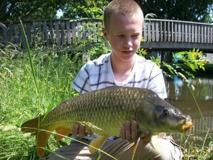

In [32]:
img = il[0]; img

We can also index with a range or a list of integers:

In [33]:
il[:1]

[<PIL.Image.Image image mode=RGB size=213x160>]

## Split validation set
Here, we need to split the files between those in the folder train and those in the folder val.

In [34]:
fn = il.items[0]; fn

Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG')

Since our filenames are `path` object, we can find the directory of the file with `.parent`.  
We need to go back two folders before since the last folders are the class names.

In [35]:
fn.parent.parent.name

'val'

In [36]:
def grandparent_splitter(fn, valid_name='valid', train_name='train'):
    gp = fn.parent.parent.name
    return True if gp==valid_name else False if gp==train_name else None

def split_by_func(items, f):
    mask = [f(o) for o in items]
    # `None` values will be filtered out
    f = [o for o,m in zip(items,mask) if m==False]
    t = [o for o,m in zip(items,mask) if m==True ]
    return f,t

here's a splitter that splits on grandparents & the validation name is `val`

In [37]:
splitter = partial(grandparent_splitter, valid_name='val')

In [38]:
%time train,valid = split_by_func(il, splitter)

CPU times: user 110 ms, sys: 1.86 ms, total: 112 ms
Wall time: 113 ms


In [39]:
len(train),len(valid)

(9469, 3925)

Now that we can split our data, let's create the class that will contain it.  
It just needs two `ItemList` to be initialized, and we create a shortcut to all the unknown attributes by trying to grab them in the `train` `ItemList`.

In [40]:
class SplitData():
    def __init__(self, train, valid): self.train,self.valid = train,valid

    def __getattr__(self,k): return getattr(self.train,k)
    #This is needed if we want to pickle SplitData and be able to load it back without recursion errors
    def __setstate__(self,data:Any): self.__dict__.update(data)

    @classmethod
    def split_by_func(cls, il, f):
        lists = map(il.new, split_by_func(il.items, f))
        return cls(*lists)

    def __repr__(self): return f'{self.__class__.__name__}\nTrain: {self.train}\nValid: {self.valid}\n'

In [41]:
sd = SplitData.split_by_func(il, splitter); sd

SplitData
Train: ImageList (9469 items)
[Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_13744.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_14053.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_9875.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_6249.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_1793.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_32134.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_7326.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_24828.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_14489.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_3129.JPEG')...]
Path: /root/.fastai/data/imagenette2-160
Valid: ImageList (3925 items)
[Path('/root/.fastai/data/imagenette2-160/val/n01440764/n01440764_4942.JPEG'), P

## Labeling
Labeling has to be done after splitting, because it uses training set information to apply to the validation set, using a Processor.

A Processor is a transformation that is applied to all the inputs once at initialization, with some state computed on the training set that is then applied without modification on the validation set (and maybe the test set or at inference time on a single item). For instance, it could be **processing texts** to **tokenize**, then **numericalize** them. In that case we want the validation set to be numericalized with exactly the same vocabulary as the training set.

Another example is in **tabular data**, where we **fill missing values** with (for instance) the median computed on the training set. That statistic is stored in the inner state of the Processor and applied on the validation set.

In our case, we want to **convert label strings to numbers** in a consistent and reproducible way. So we create a list of possible labels in the training set, and then convert our labels to numbers based on this vocab.

eg: our labels should be 0 and 2 instead of the fish names
- because when we go to do cross entropy loss we expect to see a long there not a string there
- so we need to be able to map; tench to 0, french horn to 2, etc
- need the training set to have the same mapping as the validation set
- also for any future inference
- otherwise different datasets will be talking about completely different things, when they see the number 0 for instance

going to create something called a vocab

most things we do in this labelling process is going to require some kind of Processor

In [42]:
from collections import OrderedDict

def uniqueify(x, sort=False):
    res = list(OrderedDict.fromkeys(x).keys())
    if sort: res.sort()
    return res

First, let's define the processor.  
We also define a `ProcessedItemList` with an `obj` method that can get the unprocessed items: for instance a processed label will be an index between 0 and the number of classes - 1, the corresponding `obj` will be the name of the class.  
The first one is needed by the model for the training, but the second one is better for displaying the objects.

In [43]:
class Processor():
    def process(self, items): return items

class CategoryProcessor(Processor):
    def __init__(self): self.vocab=None

    def __call__(self, items):
        #The vocab is defined on the first use.
        if self.vocab is None:
            self.vocab = uniqueify(items)
            self.otoi  = {v:k for k,v in enumerate(self.vocab)}
        return [self.proc1(o) for o in items]
    def proc1(self, item):  return self.otoi[item]

    def deprocess(self, idxs):
        assert self.vocab is not None
        return [self.deproc1(idx) for idx in idxs]
    def deproc1(self, idx): return self.vocab[idx]

Here we label according to the folders of the images, so simply fn.parent.name. We label the training set first with a newly created CategoryProcessor so that it computes its inner vocab on that set. Then we label the validation set using the same processor, which means it uses the same vocab. The end result is another SplitData object.

In [44]:
def parent_labeler(fn): return fn.parent.name

def _label_by_func(ds, f, cls=ItemList): return cls([f(o) for o in ds.items], path=ds.path)

#This is a slightly different from what was seen during the lesson,
#   we'll discuss the changes in lesson 11
class LabeledData():
    def process(self, il, proc): return il.new(compose(il.items, proc))

    def __init__(self, x, y, proc_x=None, proc_y=None):
        self.x,self.y = self.process(x, proc_x),self.process(y, proc_y)
        self.proc_x,self.proc_y = proc_x,proc_y

    def __repr__(self): return f'{self.__class__.__name__}\nx: {self.x}\ny: {self.y}\n'
    def __getitem__(self,idx): return self.x[idx],self.y[idx]
    def __len__(self): return len(self.x)

    def x_obj(self, idx): return self.obj(self.x, idx, self.proc_x)
    def y_obj(self, idx): return self.obj(self.y, idx, self.proc_y)

    def obj(self, items, idx, procs):
        isint = isinstance(idx, int) or (isinstance(idx,torch.LongTensor) and not idx.ndim)
        item = items[idx]
        for proc in reversed(listify(procs)):
            item = proc.deproc1(item) if isint else proc.deprocess(item)
        return item

    @classmethod
    def label_by_func(cls, il, f, proc_x=None, proc_y=None):
        return cls(il, _label_by_func(il, f), proc_x=proc_x, proc_y=proc_y)

def label_by_func(sd, f, proc_x=None, proc_y=None):
    train = LabeledData.label_by_func(sd.train, f, proc_x=proc_x, proc_y=proc_y)
    valid = LabeledData.label_by_func(sd.valid, f, proc_x=proc_x, proc_y=proc_y)
    return SplitData(train,valid)

Q: what is the `@classmethod` decorator doing?
A: this is the difference between an instance method and a class method
- is getting passed `cls` opposed to `self`
- not going to call this on an object of type `LabeledData` but instead call it on the `LabeledData` class itself
  - eg: `LabeledData.label_by_func(...)`
- can get away without them but they're convenient

In [45]:
ll = label_by_func(sd, parent_labeler, proc_y=CategoryProcessor())

In [46]:
assert ll.train.proc_y is ll.valid.proc_y

In [47]:
ll.train.y

ItemList (9469 items)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0...]
Path: /root/.fastai/data/imagenette2-160

In [48]:
ll.train.y.items[0], ll.train.y_obj(0), ll.train.y_obj(slice(2))

(0, 'n01440764', ['n01440764', 'n01440764'])

In [49]:
ll

SplitData
Train: LabeledData
x: ImageList (9469 items)
[Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_13744.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_14053.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_9875.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_6249.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_1793.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_32134.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_7326.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_24828.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_14489.JPEG'), Path('/root/.fastai/data/imagenette2-160/train/n01440764/n01440764_3129.JPEG')...]
Path: /root/.fastai/data/imagenette2-160
y: ItemList (9469 items)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0...]
Path: /root/.fastai/data/imagenette2

## Transform to tensor
we still can't train a model with these because we have pillow objects and we need tensors

In [50]:
ll.train[0]

(<PIL.Image.Image image mode=RGB size=179x160>, 0)

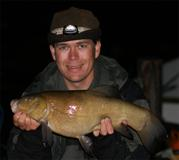

In [51]:
ll.train[0][0]

To be able to put all our images in a batch, we need them to have all the same size.  
We can do this easily in PIL.

not a great way to do it, but it's a start

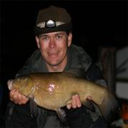

In [52]:
ll.train[0][0].resize((128,128))

The first transform resizes to a given size, then we convert the image to a by tensor before converting it to float and dividing by 255.  
We will investigate data augmentation transforms at length in notebook 10.

In [53]:
class ResizeFixed(Transform):
    _order=10
    def __init__(self,size):
        if isinstance(size,int): size=(size,size)
        self.size = size

    def __call__(self, item): return item.resize(self.size, PIL.Image.BILINEAR)

def to_byte_tensor(item):
    res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
    w,h = item.size
    return res.view(h,w,-1).permute(2,0,1)
to_byte_tensor._order=20

def to_float_tensor(item): return item.float().div_(255.)
to_float_tensor._order=30

In [54]:
tfms = [make_rgb, ResizeFixed(128), to_byte_tensor, to_float_tensor]

il = ImageList.from_files(path, tfms=tfms)
sd = SplitData.split_by_func(il, splitter)
ll = label_by_func(sd, parent_labeler, proc_y=CategoryProcessor())

Here is a little convenience function to show an image from the corresponding tensor.

note: to print them, we have to put the channel last again; `(1,2,0)`

In [55]:
def show_image(im, figsize=(3,3)):
    plt.figure(figsize=figsize)
    plt.axis('off')
    plt.imshow(im.permute(1,2,0))

In [56]:
x,y = ll.train[0]
x.shape

/tmp/ipykernel_4648/1986402166.py:10: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))


torch.Size([3, 128, 128])

can see the output is a torch object of the specified size

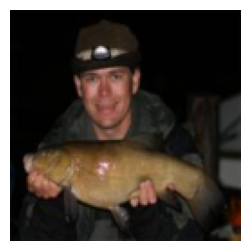

In [57]:
show_image(x)

we now have tensors that're floats and all the same size, so we can now train a model

## Modeling
### DataBunch
Now we are ready to put our datasets together in a `DataBunch`.

In [58]:
bs=64

In [59]:
train_dl,valid_dl = get_dls(ll.train,ll.valid,bs, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


grab a mini-batch:

In [60]:
x,y = next(iter(train_dl))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [61]:
x.shape

torch.Size([64, 3, 128, 128])

We can still see the images in a batch and get the corresponding classes.

'n01440764'

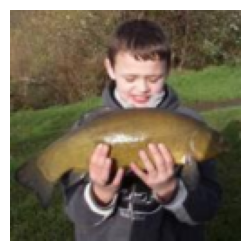

In [62]:
show_image(x[0])
ll.train.proc_y.vocab[y[0]]

can see the whole mini-batch `y` values:

In [63]:
y

tensor([0, 0, 6, 3, 7, 2, 6, 0, 0, 3, 8, 3, 8, 7, 0, 0, 7, 7, 8, 2, 8, 4, 1, 8,
        6, 7, 6, 4, 1, 1, 2, 7, 0, 3, 3, 8, 7, 2, 7, 0, 6, 0, 8, 8, 7, 9, 7, 9,
        4, 9, 2, 0, 3, 0, 4, 6, 3, 8, 8, 7, 8, 5, 8, 9])

We change a little bit our `DataBunch` to add a few attributes: `c_in` (for channel in) and `c_out` (for channel out) instead of just `c`.  
This will help when we need to build our model.

In [64]:
class DataBunch():
    def __init__(self, train_dl, valid_dl, c_in=None, c_out=None):
        self.train_dl,self.valid_dl,self.c_in,self.c_out = train_dl,valid_dl,c_in,c_out

    @property
    def train_ds(self): return self.train_dl.dataset

    @property
    def valid_ds(self): return self.valid_dl.dataset

c_in & c_out allow any models that want to be automatically created, can automatically create themselves with the correct number of inputs & outputs for our dataset

Then we define a function that goes directly from the `SplitData` to a `DataBunch`.

In [65]:
#export
def databunchify(sd, bs, c_in=None, c_out=None, **kwargs):
    dls = get_dls(sd.train, sd.valid, bs, **kwargs)
    return DataBunch(*dls, c_in=c_in, c_out=c_out)

SplitData.to_databunch = databunchify

Here's how you can add something to a previous class when you realize later that you want it
- in practice, you would go back and paste the contents of this into your `SplitData` definition
- but this is a way when you're iteratively building stuff; can **monkey-patch** your own things (aswell as pytorch or stdlib things, etc)

This gives us the full summary on how to grab our data and put it in a `DataBunch`:

In [66]:
path = untar_data(data_url)
# path = datasets.untar_data(datasets.URLs.IMAGENETTE_160)
tfms = [make_rgb, ResizeFixed(128), to_byte_tensor, to_float_tensor]

il = ImageList.from_files(path, tfms=tfms)
sd = SplitData.split_by_func(il, partial(grandparent_splitter, valid_name='val'))
ll = label_by_func(sd, parent_labeler, proc_y=CategoryProcessor())
data = ll.to_databunch(bs, c_in=3, c_out=10, num_workers=4)

1. get the path / untar the data
2. get the transforms
3. get the item list, passing in the transforms
4. split the data, using the grandparent & this validation name
5. label it (using parent_labeler)
5. turn it into a databunch, with: bs, c_in=3, c_out=10, and 4 processors

## Model

here's our callback fns from last time:

In [67]:
cbfs = [partial(AvgStatsCallback,accuracy),
        CudaCallback]

We will normalize with the statistics from a batch.

In [68]:
m,s = x.mean((0,2,3)).cuda(),x.std((0,2,3)).cuda()
m,s

(tensor([0.4557, 0.4477, 0.4012], device='cuda:0'),
 tensor([0.2848, 0.2780, 0.2971], device='cuda:0'))

in the past we've normalized MNIST with only 1 channel.  
we now have 3 channels, so we need to make sure we take the mean over the other channels so we get a 3 channel mean / 3 channel std

so let's define a fn that normalizes things that are 3 channels:

In [69]:
#export
def normalize_chan(x, mean, std):
    return (x-mean[...,None,None]) / std[...,None,None]

_m = tensor([0.47, 0.48, 0.45])
_s = tensor([0.29, 0.28, 0.30])
norm_imagenette = partial(normalize_chan, mean=_m.cuda(), std=_s.cuda())

note: we're just broadcasting here: `x-mean[...,None,None]) / std[...,None,None]`

add that as a callback:

In [70]:
cbfs.append(partial(BatchTransformXCallback, norm_imagenette))

we will create a conv net with this number of layers:

In [71]:
nfs = [64,64,128,256]

We build our model using Bag of Tricks for Image Classification with Convolutional Neural Networks, in particular: we don't use a big conv 7x7 at first but three 3x3 convs, and don't go directly from 3 channels to 64 but progressively add those.

In [72]:
#export
import math
def prev_pow_2(x): return 2**math.floor(math.log2(x))

def get_cnn_layers(data, nfs, layer, **kwargs):
    def f(ni, nf, stride=2): return layer(ni, nf, 3, stride=stride, **kwargs)
    l1 = data.c_in
    l2 = prev_pow_2(l1*3*3)
    layers =  [f(l1  , l2  , stride=1),
               f(l2  , l2*2, stride=2),
               f(l2*2, l2*4, stride=2)]
    nfs = [l2*4] + nfs
    layers += [f(nfs[i], nfs[i+1]) for i in range(len(nfs)-1)]
    layers += [nn.AdaptiveAvgPool2d(1), Lambda(flatten),
               nn.Linear(nfs[-1], data.c_out)]
    return layers

def get_cnn_model(data, nfs, layer, **kwargs):
    return nn.Sequential(*get_cnn_layers(data, nfs, layer, **kwargs))

def get_learn_run(nfs, data, lr, layer, cbs=None, opt_func=None, **kwargs):
    model = get_cnn_model(data, nfs, layer, **kwargs)
    init_cnn(model)
    return get_runner(model, data, lr=lr, cbs=cbs, opt_func=opt_func)

do our 1cycle sheduling using `cos_1cycle_anneal`:

In [73]:
sched = combine_scheds([0.3,0.7], cos_1cycle_anneal(0.1,0.3,0.05))

In [74]:
learn,run = get_learn_run(nfs, data, 0.2, conv_layer, cbs=cbfs+[
    partial(ParamScheduler, 'lr', sched)
])

Let's have a look at our model using Hooks.  
We print the layers and the shapes of their outputs.

In [75]:
#export
def model_summary(run, learn, data, find_all=False):
    xb,yb = get_batch(data.valid_dl, run)
    device = next(learn.model.parameters()).device #Model may not be on the GPU yet
    xb,yb = xb.to(device),yb.to(device)
    mods = find_modules(learn.model, is_lin_layer) if find_all else learn.model.children()
    f = lambda hook,mod,inp,out: print(f"{mod}\n{out.shape}\n")
    with Hooks(mods, f) as hooks: learn.model(xb)

In [76]:
model_summary(run, learn, data)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): GeneralRelu()
  (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
torch.Size([128, 16, 128, 128])

Sequential(
  (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): GeneralRelu()
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
torch.Size([128, 32, 64, 64])

Sequential(
  (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): GeneralRelu()
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
torch.Size([128, 64, 32, 32])

Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): GeneralRelu()
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
torch.Size([128, 64, 16, 16])

Sequential(
  (0): Conv2d(64, 64, kernel_size=(

In [77]:
%time run.fit(5, learn)

train: [1.8054339736904637, tensor(0.3735, device='cuda:0')]
valid: [1.7553687300955414, tensor(0.4199, device='cuda:0')]
train: [1.397649051345179, tensor(0.5363, device='cuda:0')]
valid: [1.3906317177547771, tensor(0.5404, device='cuda:0')]
train: [0.9942830511075615, tensor(0.6719, device='cuda:0')]
valid: [1.1743196407245222, tensor(0.6201, device='cuda:0')]
train: [0.6165990770045675, tensor(0.8016, device='cuda:0')]
valid: [1.1160846685907644, tensor(0.6530, device='cuda:0')]
train: [0.32841903101568276, tensor(0.9131, device='cuda:0')]
valid: [1.0896313943073248, tensor(0.6622, device='cuda:0')]
CPU times: user 9.54 s, sys: 4.21 s, total: 13.7 s
Wall time: 1min 12s


The leaderboard as this notebook is written has ~85% accuracy for 5 epochs at 128px size, so we're definitely on the right track!